In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df=pd.read_csv("lahore_flats_feature_engineered.csv")

In [125]:
df.columns

Index(['name', 'marla', 'area_sqft', 'floor_number', 'total_floors',
       'built_year', 'address', 'description', 'floor', 'floors_in_building',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms'],
      dtype='object')

In [126]:
df = df.drop(columns=["name", "description"])

In [127]:
df = df.drop(columns=["address"])

In [128]:
df[['floor_number','total_floors','floor','floors_in_building']]

,floor_number,total_floors,floor,floors_in_building
0,8.0,11.0,8.0,11.0
1,NaN,13.0,NaN,13.0
2,6.0,11.0,6.0,11.0
3,NaN,8.0,NaN,8.0
4,1.0,9.0,1.0,9.0
...,...,...,...,...
2494,2.0,7.0,2.0,7.0
2495,1.0,NaN,1.0,NaN
2496,NaN,7.0,NaN,7.0
2497,NaN,NaN,NaN,NaN


In [129]:
df = df.drop(columns=["floor", "floors_in_building"])


In [130]:
df.columns

Index(['marla', 'area_sqft', 'floor_number', 'total_floors', 'built_year',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms'],
      dtype='object')

In [131]:
df["area_sqft"] = pd.to_numeric(df["area_sqft"], errors="coerce")
df["price_per_sqft"] = df["price"] / df["area_sqft"]


In [132]:
df.columns

Index(['marla', 'area_sqft', 'floor_number', 'total_floors', 'built_year',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'price_per_sqft'],
      dtype='object')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   marla                   2499 non-null   float64
 1   area_sqft               2499 non-null   float64
 2   floor_number            1095 non-null   float64
 3   total_floors            1352 non-null   float64
 4   built_year              1800 non-null   float64
 5   bedrooms                2145 non-null   float64
 6   bathrooms               2146 non-null   float64
 7   kitchens                2074 non-null   float64
 8   servant_quarters        1657 non-null   float64
 9   store_rooms             1723 non-null   float64
 10  price                   2499 non-null   int64  
 11  society                 2499 non-null   object 
 12  luxury_score            2499 non-null   int64  
 13  drawing_room            2499 non-null   int64  
 14  dining_room             2499 non-null   

In [134]:
df.duplicated().sum()

np.int64(36)

In [135]:
df = df.drop_duplicates()

In [136]:
df.shape

(2463, 24)

In [137]:
df.head()

,marla,area_sqft,floor_number,total_floors,built_year,bedrooms,bathrooms,kitchens,servant_quarters,store_rooms,...,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,price_per_sqft
0,1.3,353.925,8.0,11.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1,1,1,0,0,0,0,0,0,15257.469803
1,1.8,490.050,NaN,13.0,NaN,1.0,1.0,1.0,NaN,NaN,...,0,1,0,0,0,0,0,0,0,4401.591674
2,2.2,598.950,6.0,11.0,NaN,1.0,1.0,1.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,13356.707572
3,2.2,598.950,NaN,8.0,2023.0,NaN,1.0,1.0,1.0,1.0,...,1,1,1,1,1,1,1,1,1,3339.176893
4,2.2,598.950,1.0,9.0,2023.0,1.0,1.0,1.0,1.0,1.0,...,1,1,1,1,1,1,1,1,1,4173.971116


## Univarient Analysis
- Col dist
- outliers
- missing val

## society                 

In [138]:
df['society'].value_counts().shape

(87,)

In [139]:
df['society'].value_counts()

society
Askari 11         499
Gulberg           293
Askari 10         288
DHA Defence       250
Raiwind Road      232
                 ... 
Sant Nagar          1
Super Town          1
Saadi Park          1
EME Society         1
Cavalry Ground      1
Name: count, Length: 87, dtype: int64

In [140]:
df[df["society"] != "Askari 11"]["society"].value_counts(normalize=True).cumsum().head(75)


society
Gulberg                                0.149185
Askari 10                              0.295825
DHA Defence                            0.423116
Raiwind Road                           0.541242
Gulberg 3                              0.624745
                                         ...   
Mustafa Town                           0.992363
Abdul Sattar Edhi Road                 0.992872
Bahria Education & Medical City        0.993381
Shabbir Town - Executive Apartments    0.993890
Davis Road                             0.994399
Name: proportion, Length: 75, dtype: float64

In [141]:
society_counts = df["society"].value_counts()

frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}

frequency_bins


{'Very High (>100)': np.int64(6),
 'High (50-100)': np.int64(4),
 'Average (10-49)': np.int64(12),
 'Low (2-9)': np.int64(39),
 'Very Low (1)': np.int64(26)}

<Axes: xlabel='society'>

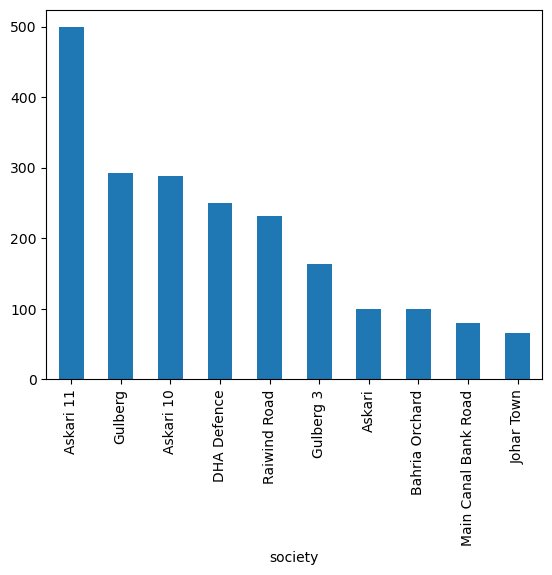

In [142]:
df["society"].value_counts().head(10).plot(kind='bar')

In [143]:
df['society'].isnull().sum()

np.int64(0)

In [144]:
dict(df['society'].value_counts())

{'Askari 11': np.int64(499),
 'Gulberg': np.int64(293),
 'Askari 10': np.int64(288),
 'DHA Defence': np.int64(250),
 'Raiwind Road': np.int64(232),
 'Gulberg 3': np.int64(164),
 'Askari': np.int64(100),
 'Bahria Orchard': np.int64(100),
 'Main Canal Bank Road': np.int64(80),
 'Johar Town': np.int64(66),
 'Dream Gardens': np.int64(39),
 'Shanghai Road': np.int64(32),
 'Bahria Town': np.int64(26),
 'Khayaban-e-Amin': np.int64(17),
 'Jubilee Town': np.int64(14),
 'New Lahore City': np.int64(14),
 'Sukh Chayn Gardens': np.int64(13),
 'Ferozepur Road': np.int64(13),
 'Land Breeze Housing Society': np.int64(12),
 'Allama Iqbal Town': np.int64(11),
 'Paragon City': np.int64(11),
 'Garden Town': np.int64(10),
 'Wapda Town': np.int64(9),
 'Izmir Town': np.int64(9),
 'Model Town': np.int64(9),
 'Multan Road': np.int64(8),
 'Lake City': np.int64(8),
 'PAF Falcon Complex': np.int64(7),
 'Nespak Housing Scheme': np.int64(5),
 'Jail Road': np.int64(5),
 'Shadman 2': np.int64(5),
 'Pine Avenue': np.i

In [145]:
df["society"] = df["society"].replace(r"^Gulberg 3(\s+\d+)?$", "Gulberg", regex=True)

In [146]:
df["society"] = df["society"].replace(r"^Main Market(\s+\d+)?$", "Gulberg", regex=True)

### Observability
- 87 socities/area
- {'Very High (>100)': np.int64(5),
- 'High (50-100)': np.int64(4),
- 'Average (10-49)': np.int64(12),
- 'Low (2-9)': np.int64(38),
- 'Very Low (1)': np.int64(24)}
- no missing val

## Price

In [147]:
df['price'].isnull().sum()

np.int64(0)

In [148]:
df['price'].value_counts()

price
35000000    55
45000000    44
27500000    37
32500000    33
44000000    31
            ..
5412000      1
7250000      1
2790000      1
2772000      1
5652000      1
Name: count, Length: 505, dtype: int64

In [149]:
df['price'].describe()

count    2.463000e+03
mean     2.427430e+07
std      1.686481e+07
min      1.800000e+06
25%      9.000000e+06
50%      2.430000e+07
75%      3.550000e+07
max      1.800000e+08
Name: price, dtype: float64

In [150]:
df["price_crore"] = df["price"] / 1e7
# df["price_lakh"] = df["price"] / 1e5


In [151]:
df['price'].min()

1800000

In [152]:
df['price_crore'].min()

0.18

In [153]:
df["price_crore"] = df["price"] / 1e7
p=df['price']
df = df.drop(columns=["price"]).rename(columns={"price_crore": "price"})

In [154]:
p.iloc[90]

np.int64(25000000)

In [155]:
df['price'].iloc[90]

np.float64(2.5)

In [156]:
df['price'].describe()

count    2463.000000
mean        2.427430
std         1.686481
min         0.180000
25%         0.900000
50%         2.430000
75%         3.550000
max        18.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

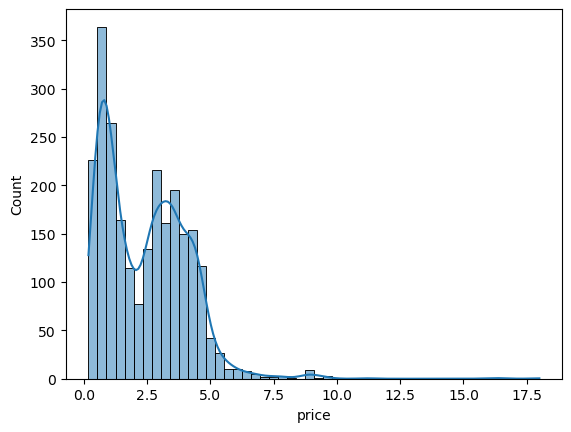

In [157]:
sns.histplot(df["price"], kde=True, bins=50)

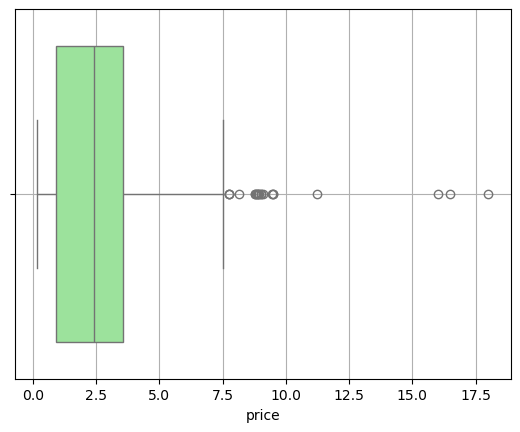

In [158]:
sns.boxplot(x=df["price"], color="lightgreen")
plt.grid()


`Descriptive Statistics` **(df['price'].describe())**
- Count: 2,463 non-missing price entries  
- Mean: ~2.43 crore  
- Median (50%): 2.43 crore  
- Std Dev: ~1.69  
- Range: 0.18 to 18.00 crore  
- IQR: 0.90 to 3.55 crore  

**Visualizations**
- Histogram: Strong right-skew; most prices are below ~5 crore, with a long tail.  
- Box Plot: Several high-end outliers, with values extending up to ~18 crore.  

**Missing Values**
- Missing count: 0


In [159]:
# Skewness and Kurtosis
skewness = df["price"].skew() # how much your data skwed 
kurtosis = df["price"].kurt() # how much haviness in tail
print(skewness, kurtosis)


1.3768192864287199 6.720583576378985


- **Skewness:** ~1.38 → positively skewed (right‑tailed). Most properties are lower‑priced with a few high‑priced outliers.  
- **Kurtosis:** ~6.72 → heavier tails than normal, indicating more extreme values/outliers.  


In [160]:
# Quantile Analysis
quantiles = df["price"].quantile([0.01, 0.05, 0.95, 0.99])
quantiles


0.01    0.300
0.05    0.450
0.95    4.850
0.99    6.938
Name: price, dtype: float64

**Quantile Analysis**
- **1% Quantile:** 1% of properties are priced below **0.30 crore**.  
- **5% Quantile:** 5% of properties are priced below **0.45 crore**.  
- **95% Quantile:** 95% of properties are priced below **4.85 crore**.  
- **99% Quantile:** 99% of properties are priced below **6.94 crore**, so only 1% are higher.  


In [161]:
# Identify potential outliers using IQR method
Q1 = df["price"].describe()["25%"]
Q3 = df["price"].describe()["75%"]
IQR = Q3 - Q1
IQR


np.float64(2.65)

In [162]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)


-3.0749999999999997 7.5249999999999995


In [163]:
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
outliers.shape

(21, 24)

In [164]:
outliers["price"].describe()


count    21.000000
mean     10.028095
std       2.961237
min       7.740000
25%       8.780000
50%       8.950000
75%       9.500000
max      18.000000
Name: price, dtype: float64

**Outliers Analysis (using IQR method):**
- Based on the IQR method, there are **21** properties considered outliers.  
- These outliers have an **average price of ~10.03 crores**.  
- The **range** for these outliers is **7.74 to 18.00 crores**.  


<Axes: xlabel='price'>

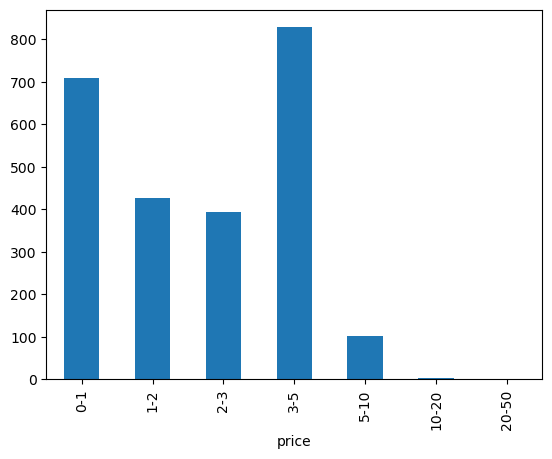

In [165]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df["price"], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind="bar")


- Most listings fall in the **0–1** and **3–5 crore** bins, with moderate counts in **1–2** and **2–3**.  
- There’s a sharp drop after **5 crore**; very few listings appear above **10 crore**.  


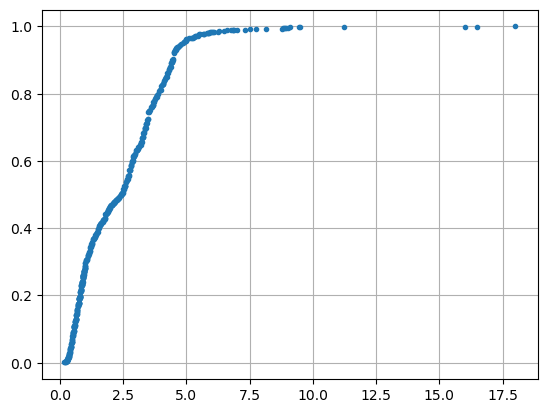

In [166]:
# ecdf plot
ecdf = df["price"].value_counts().sort_index().cumsum() / len(df["price"])
plt.plot(ecdf.index, ecdf, marker=".", linestyle="none")
plt.grid()


In [167]:
df.shape

(2463, 24)

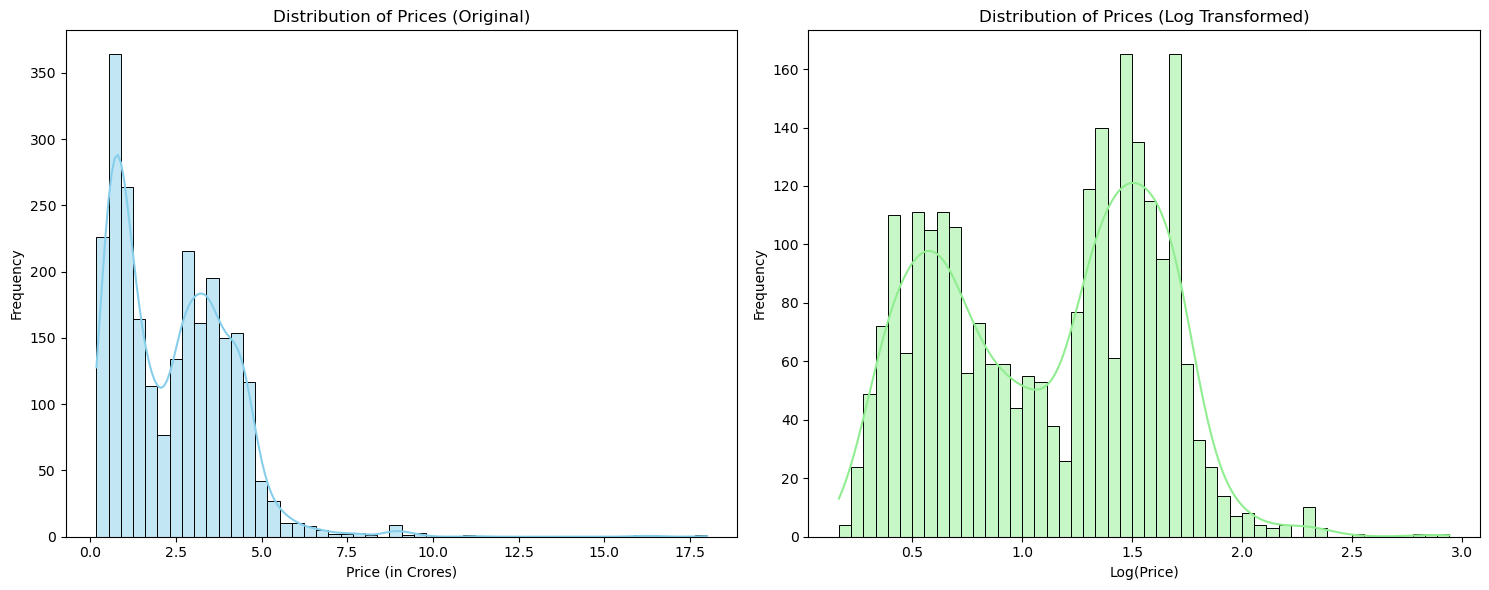

In [168]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df["price"], kde=True, bins=50, color="skyblue")
plt.title("Distribution of Prices (Original)")
plt.xlabel("Price (in Crores)")
plt.ylabel("Frequency")

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["price"]), kde=True, bins=50, color="lightgreen")
plt.title("Distribution of Prices (Log Transformed)")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


`np.log1p(x)` computes `ln(1 + x)`, which is more numerically stable for values near 0.  
It’s useful for transforming the price column because it safely handles zero values.  
To reverse it, use `np.expm1(y)` which computes `e^y - 1`.


In [169]:
# Skewness & kurtosis (log-transformed)
skewness = np.log1p(df["price"]).skew()
kurtosis = np.log1p(df["price"]).kurt()
print(skewness, kurtosis)


-0.03703527124728626 -1.0438833009018773


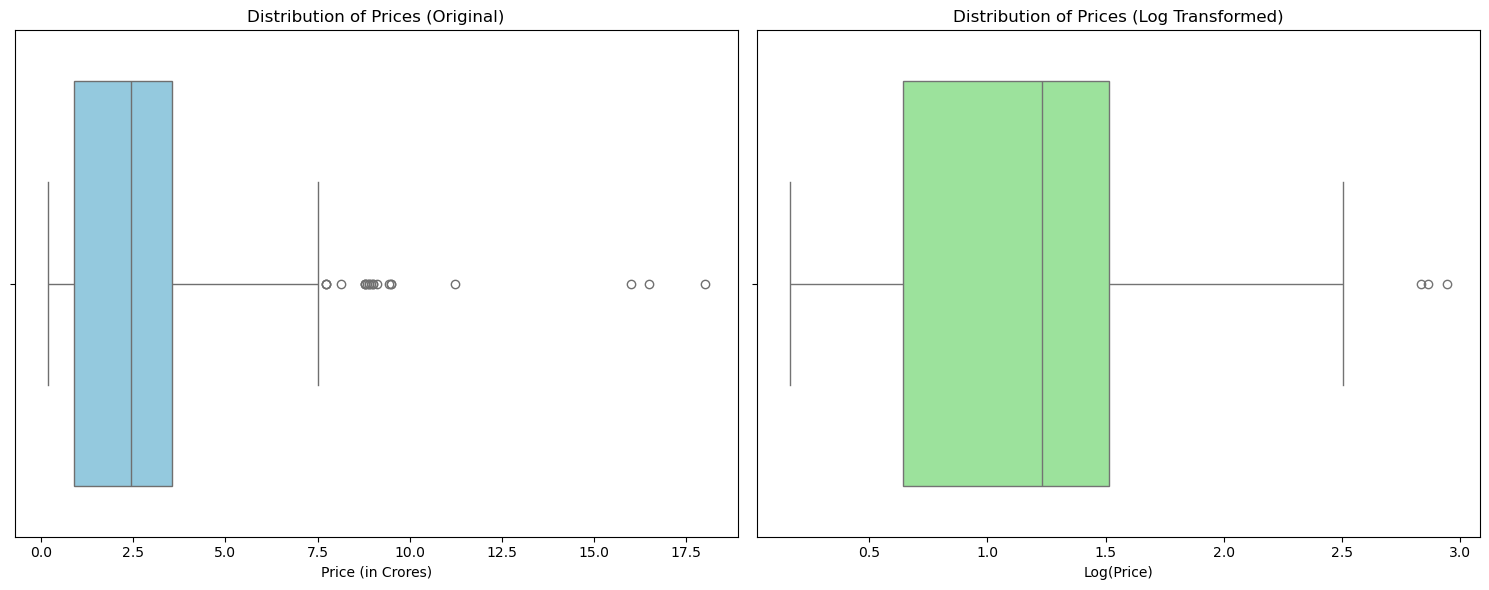

In [170]:
plt.figure(figsize=(15, 6))

# Box plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df["price"], color="skyblue")
plt.title("Distribution of Prices (Original)")
plt.xlabel("Price (in Crores)")

# Box plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df["price"]), color="lightgreen")
plt.title("Distribution of Prices (Log Transformed)")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()


## price per sqft

In [171]:
df["price_per_sqft"].isnull().sum()

np.int64(0)

In [172]:
df["price_per_sqft"].describe()

count      2463.000000
mean      16555.649729
std       12980.443281
min         966.603837
25%       10407.101316
50%       13279.649643
75%       19823.152055
max      413223.140496
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

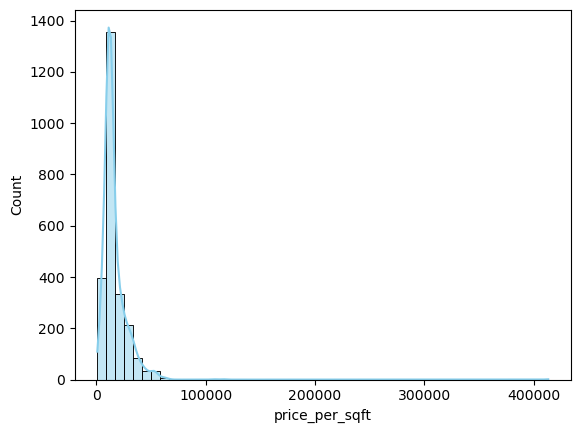

In [173]:
sns.histplot(df["price_per_sqft"], bins=50, color="skyblue", kde=True)


<Axes: xlabel='price_per_sqft'>

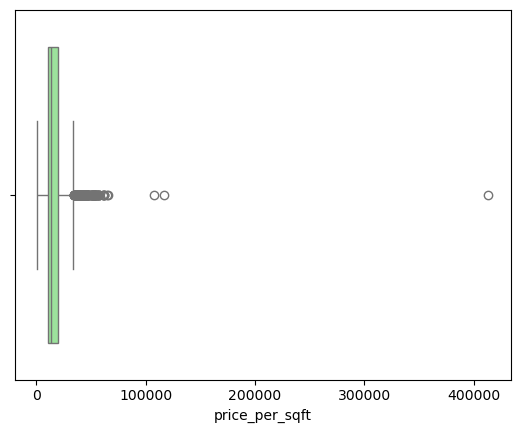

In [174]:
sns.boxplot(x=df["price_per_sqft"], color="lightgreen")


**Price per sqft — Observations**
- The distribution is strongly right‑skewed with a long high‑price tail.  
- Box plot shows several high‑end outliers; most listings cluster in a tighter lower range.  
- No missing values (`count = 2463`).  
- Summary stats: mean ≈ 16,556; median ≈ 13,280; max ≈ 413,223.  


## bedrooms

In [175]:
df["bedrooms"].isnull().sum()

np.int64(352)

<Axes: xlabel='bedrooms'>

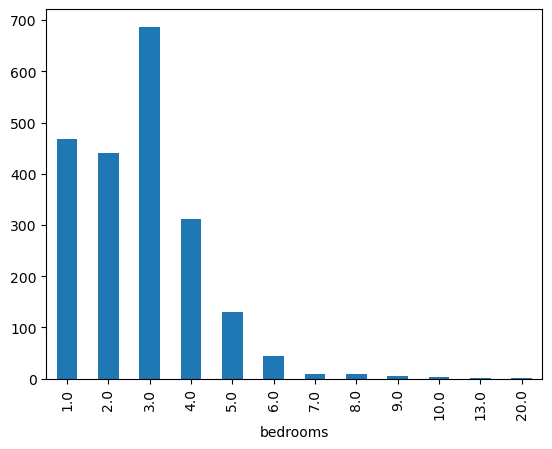

In [176]:
df["bedrooms"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

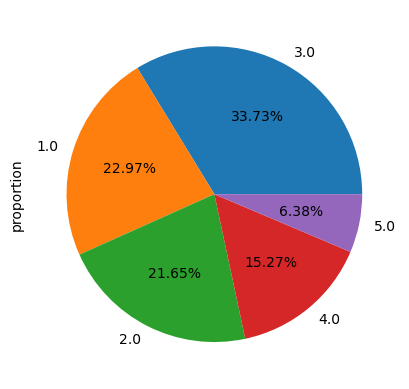

In [177]:
df["bedrooms"].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")


## bathrooms

In [178]:
df["bathrooms"].isnull().sum()

np.int64(351)

<Axes: xlabel='bathrooms'>

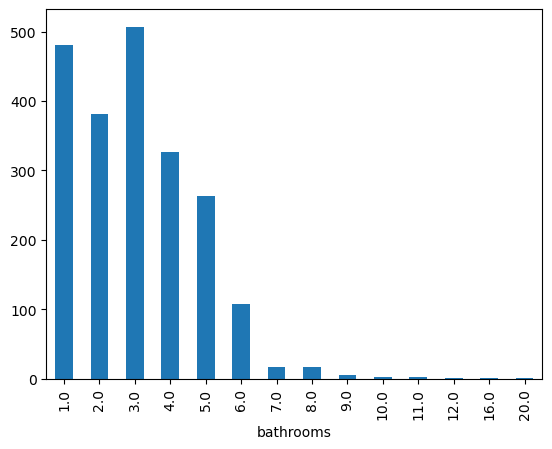

In [179]:
df["bathrooms"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

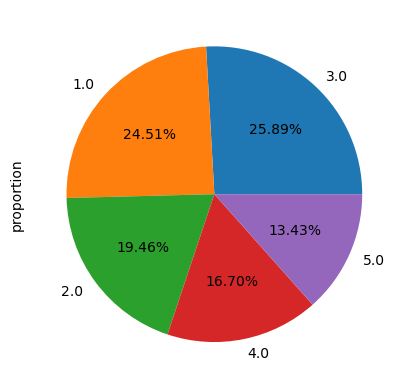

In [180]:
df['bathrooms'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## kitchens

In [181]:
df["kitchens"].isnull().sum()


np.int64(423)

<Axes: xlabel='kitchens'>

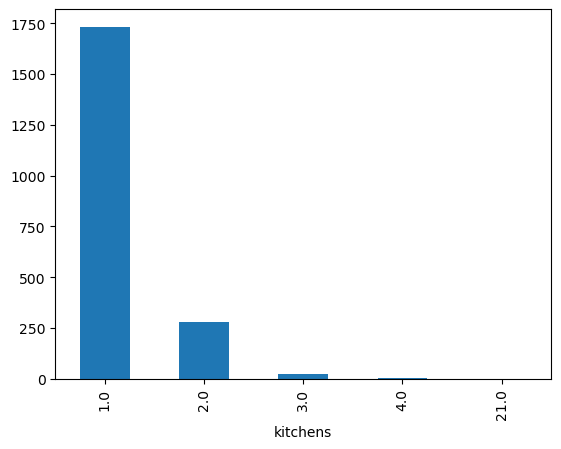

In [182]:
df["kitchens"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

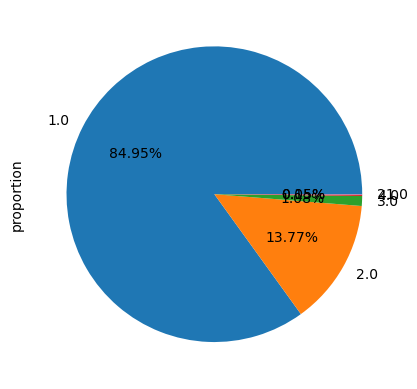

In [183]:
df['kitchens'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## servant_quarters

In [184]:
df["servant_quarters"].isnull().sum()


np.int64(835)

<Axes: xlabel='servant_quarters'>

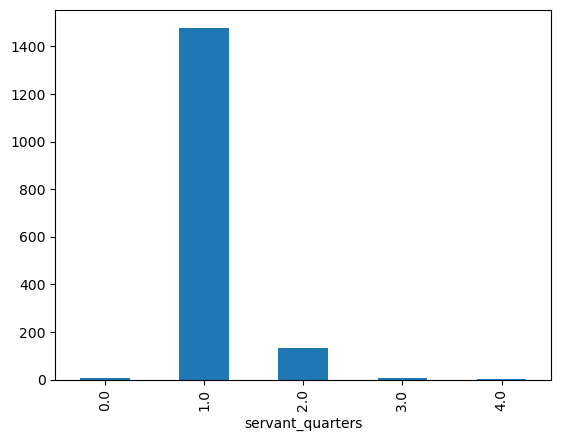

In [185]:
df["servant_quarters"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

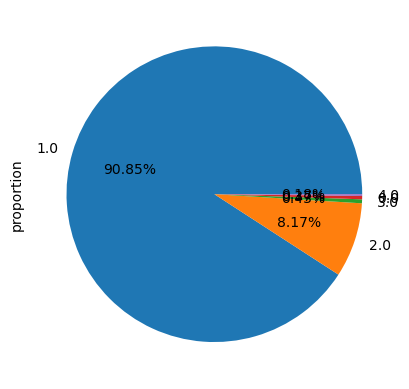

In [186]:
df['servant_quarters'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## store_rooms

In [187]:
df["store_rooms"].isnull().sum()


np.int64(770)

<Axes: xlabel='store_rooms'>

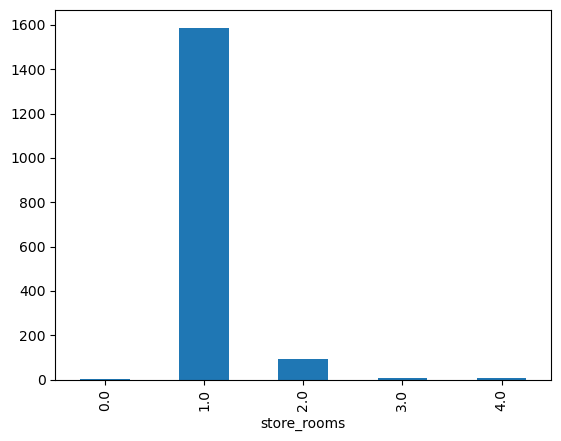

In [188]:
df["store_rooms"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

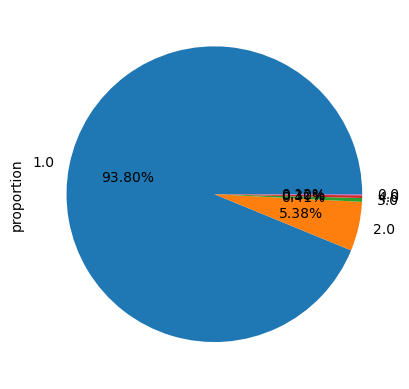

In [189]:
df['store_rooms'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## drawing_room

In [190]:
df["drawing_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='drawing_room'>

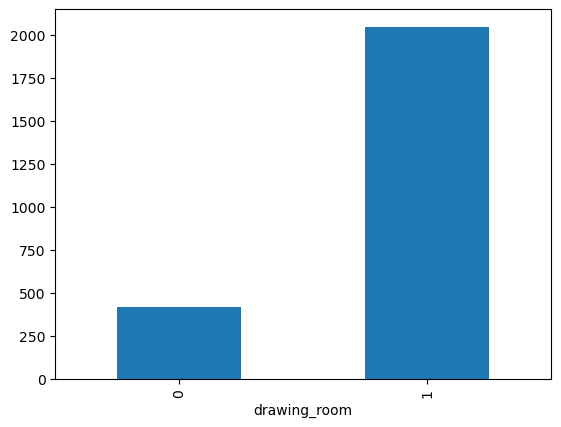

In [191]:
df["drawing_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

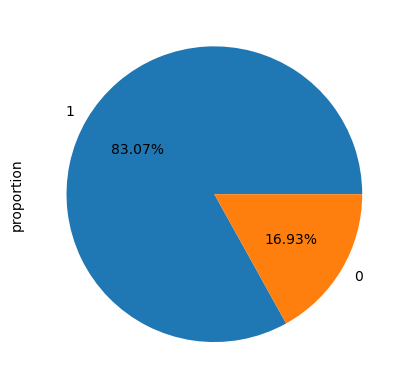

In [192]:
df['drawing_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## dining_room

In [193]:
df["dining_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='dining_room'>

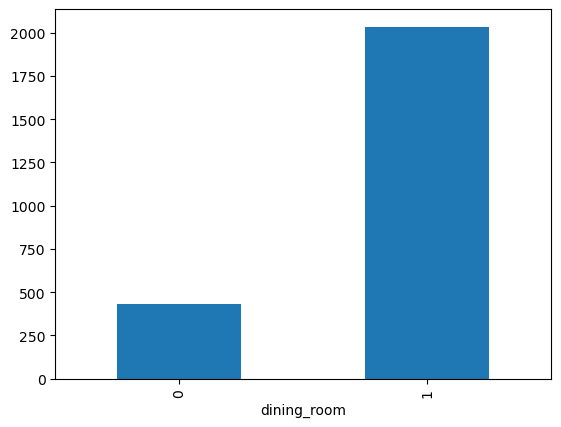

In [194]:
df["dining_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

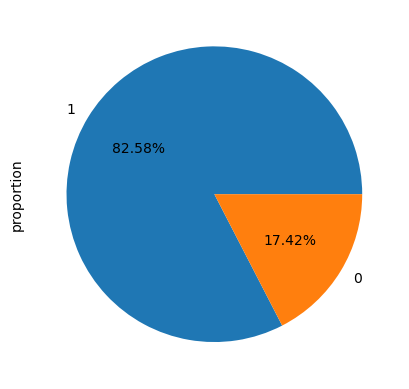

In [195]:
df['dining_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## lounge_or_sitting_room

In [196]:
df["lounge_or_sitting_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='lounge_or_sitting_room'>

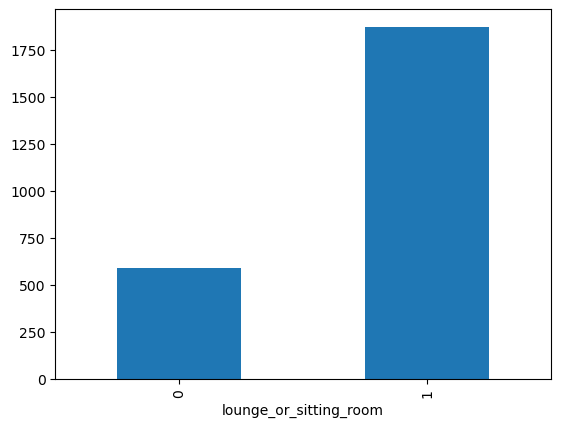

In [197]:
df["lounge_or_sitting_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

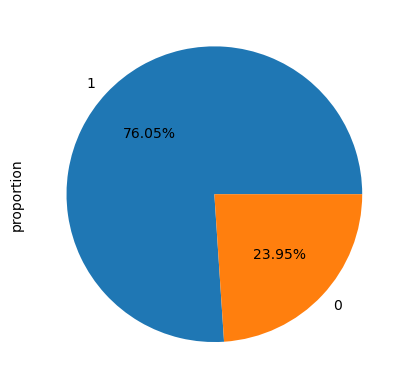

In [198]:
df['lounge_or_sitting_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## laundry_room

In [199]:
df["laundry_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='laundry_room'>

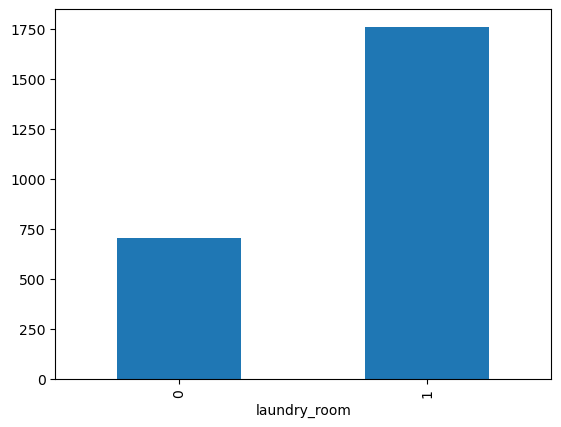

In [200]:
df["laundry_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

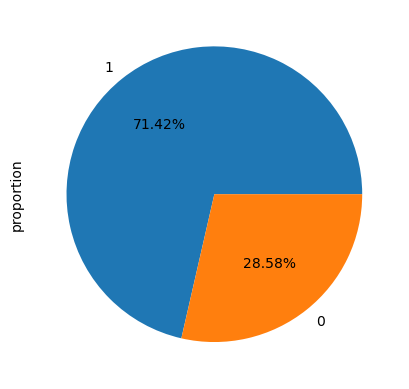

In [201]:
df['laundry_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## study_room

In [202]:
df["study_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='study_room'>

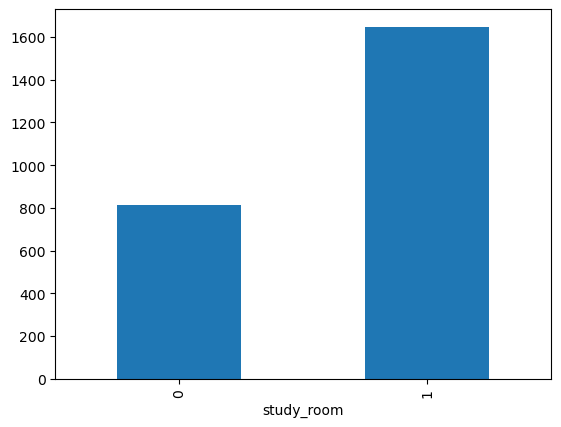

In [203]:
df["study_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

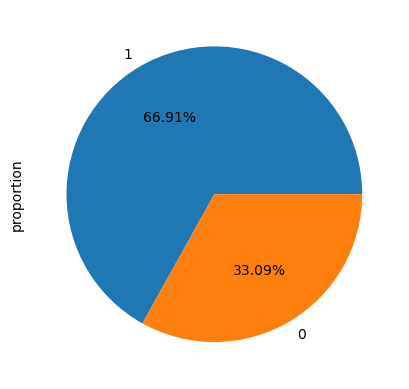

In [204]:
df['study_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## prayer_room

In [205]:
df["prayer_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='prayer_room'>

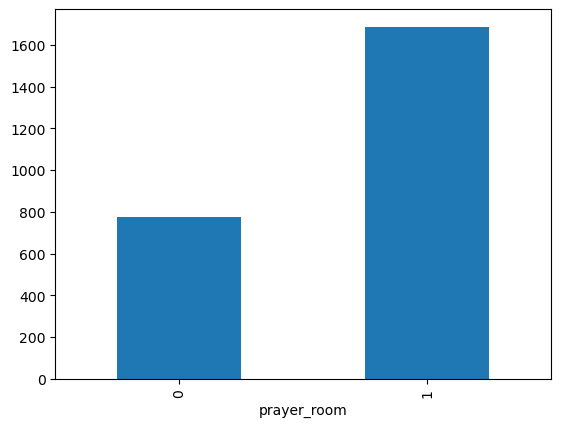

In [206]:
df["prayer_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

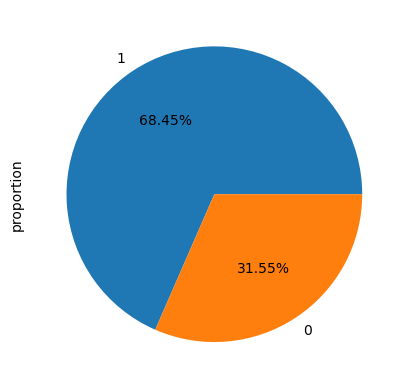

In [207]:
df['prayer_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## powder_room

In [208]:
df["powder_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='powder_room'>

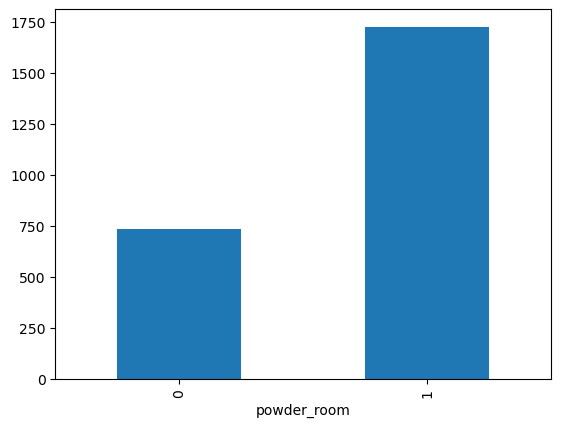

In [209]:
df["powder_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

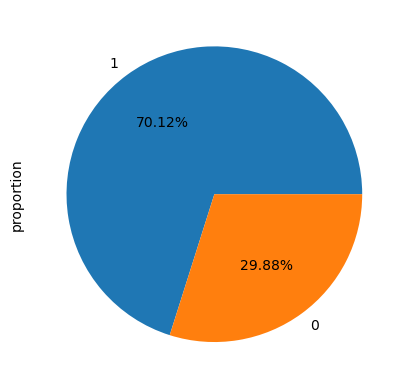

In [210]:
df['powder_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## gym

In [211]:
df["gym"].isnull().sum()


np.int64(0)

<Axes: xlabel='gym'>

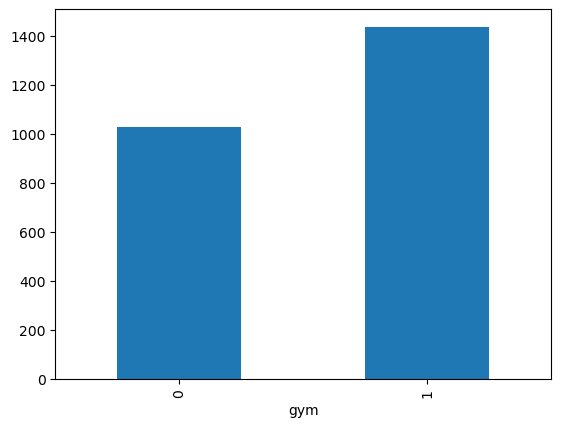

In [212]:
df["gym"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

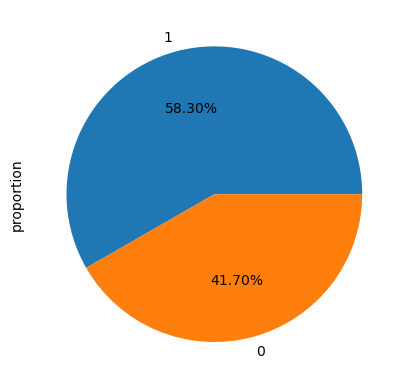

In [213]:
df['gym'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## steam_room

In [214]:
df["steam_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='steam_room'>

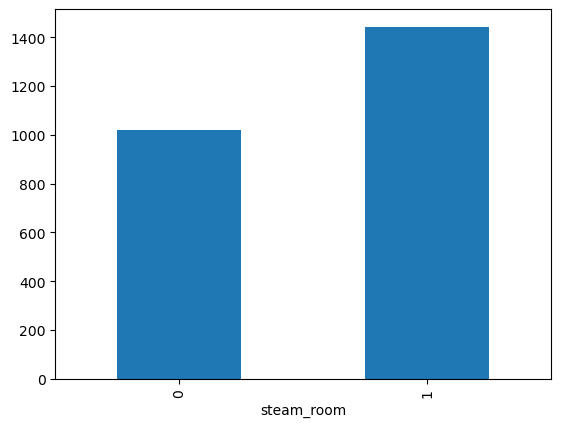

In [215]:
df["steam_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

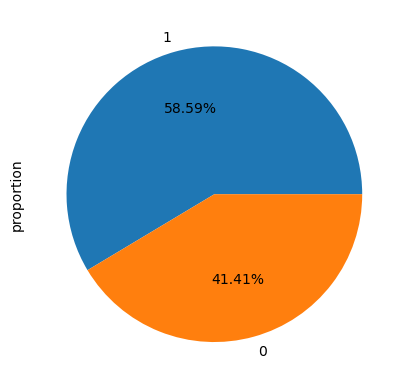

In [216]:
df['steam_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## other rooms

In [217]:
df["other_rooms"].isnull().sum()

np.int64(0)

<Axes: xlabel='other_rooms'>

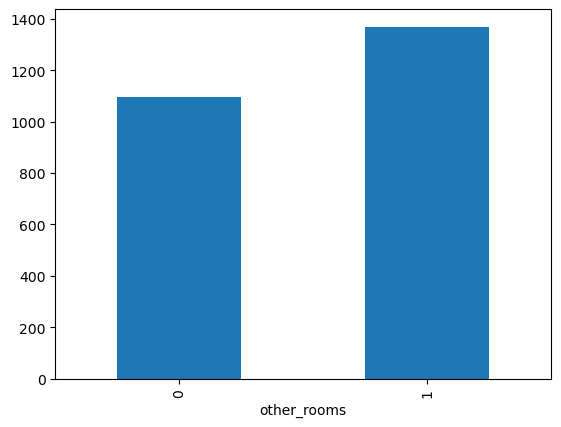

In [218]:
df["other_rooms"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

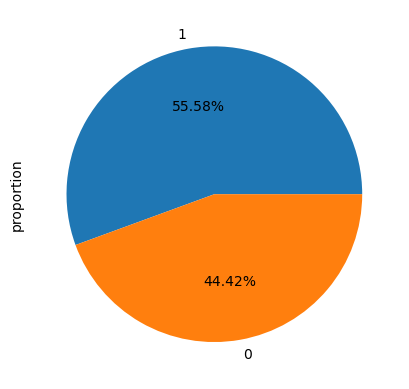

In [219]:
df['other_rooms'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## floor num

In [220]:
df['floor_number'].isnull().sum()


np.int64(1390)

In [221]:
df['floor_number'].describe()

count    1073.000000
mean        8.137931
std        72.150105
min         1.000000
25%         1.000000
50%         4.000000
75%         7.000000
max      2018.000000
Name: floor_number, dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0'),
  Text(5, 0, '6.0'),
  Text(6, 0, '7.0'),
  Text(7, 0, '8.0'),
  Text(8, 0, '9.0'),
  Text(9, 0, '10.0'),
  Text(10, 0, '11.0'),
  Text(11, 0, '12.0'),
  Text(12, 0, '13.0'),
  Text(13, 0, '14.0'),
  Text(14, 0, '15.0'),
  Text(15, 0, '16.0'),
  Text(16, 0, '17.0'),
  Text(17, 0, '18.0'),
  Text(18, 0, '19.0'),
  Text(19, 0, '20.0'),
  Text(20, 0, '21.0'),
  Text(21, 0, '22.0'),
  Text(22, 0, '23.0'),
  Text(23, 0, '24.0'),
  Text(24, 0, '25.0'),
  Text(25, 0, '26.0'),
  Text(26, 0, '27.0'),
  Text(27, 0, '30.0'),
  Text(28, 0, '33.0'),
  Text(29, 0, '35.0'),
  Text(30, 0, '1234.0'),
  Text(31, 0, '2018.0')])

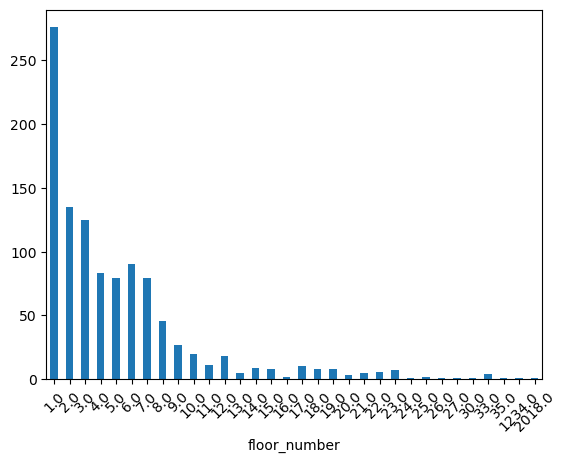

In [222]:
df["floor_number"].value_counts().sort_index().plot(kind="bar")
plt.xticks(rotation=45)

<Axes: xlabel='floor_number'>

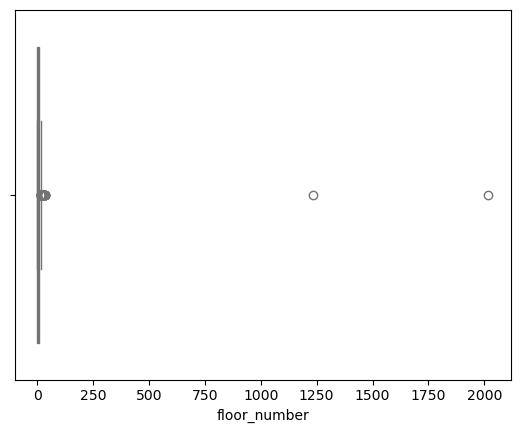

In [223]:
sns.boxplot(x=df["floor_number"], color="lightgreen")


- **Missingness:** 1,390 missing values; only 1,073 valid floor numbers.  
- **Typical floors:** Median = 4, 75% of listings are at floor ≤ 7 (most are low‑rise).  
- **Outliers:** Extremely high values (max = 2018) are clear data errors and dominate the tail.  
- **Box plot:** Heavy right tail with a few extreme points; most values cluster near the lower floors.  


## built_year

In [224]:
df['built_year'].isnull().sum()

np.int64(688)

In [225]:
dict(df['built_year'].value_counts())

{2025.0: np.int64(604),
 2024.0: np.int64(267),
 2023.0: np.int64(113),
 2026.0: np.int64(98),
 2022.0: np.int64(93),
 2027.0: np.int64(77),
 2018.0: np.int64(75),
 2020.0: np.int64(69),
 2021.0: np.int64(68),
 2017.0: np.int64(54),
 2029.0: np.int64(47),
 2028.0: np.int64(45),
 2015.0: np.int64(30),
 2019.0: np.int64(29),
 2016.0: np.int64(16),
 2030.0: np.int64(12),
 2010.0: np.int64(10),
 2012.0: np.int64(9),
 2000.0: np.int64(7),
 1992.0: np.int64(6),
 2005.0: np.int64(5),
 2014.0: np.int64(5),
 1998.0: np.int64(4),
 2001.0: np.int64(3),
 2003.0: np.int64(3),
 1985.0: np.int64(3),
 2011.0: np.int64(3),
 2008.0: np.int64(3),
 1986.0: np.int64(2),
 1999.0: np.int64(2),
 2002.0: np.int64(2),
 2004.0: np.int64(2),
 20242.0: np.int64(2),
 1990.0: np.int64(2),
 1994.0: np.int64(1),
 1987.0: np.int64(1),
 2056.0: np.int64(1),
 1996.0: np.int64(1),
 2007.0: np.int64(1)}

In [226]:
import numpy as np
import pandas as pd

current_year = 2025  # set as needed

def classify_year(y):
    if pd.isna(y):
        return "Undefined"
    if y > current_year:
        return "Under construction"
    age = current_year - y
    if age <= 3:
        return "New Property"
    if age <= 10:
        return "Relatively New"
    if age <= 20:
        return "Moderately Old"
    return "Old Property"

df["built_year_category"] = df["built_year"].apply(classify_year)

In [227]:
df["built_year_category"].value_counts()

built_year_category
New Property          1077
Undefined              688
Relatively New         341
Under construction     282
Old Property            39
Moderately Old          36
Name: count, dtype: int64

In [228]:
df = df.rename(columns={"built_year_category": "agePossession"})

In [229]:
df = df.drop(columns=["built_year"])

## area

In [230]:
df["area_sqft"].isnull().sum()

np.int64(0)

In [231]:
df["area_sqft"].describe()


count    2463.00000
mean     1689.36486
std      1082.65899
min       108.90000
25%       653.40000
50%      1361.25000
75%      2722.50000
max      7759.12500
Name: area_sqft, dtype: float64

<Axes: xlabel='area_sqft', ylabel='Count'>

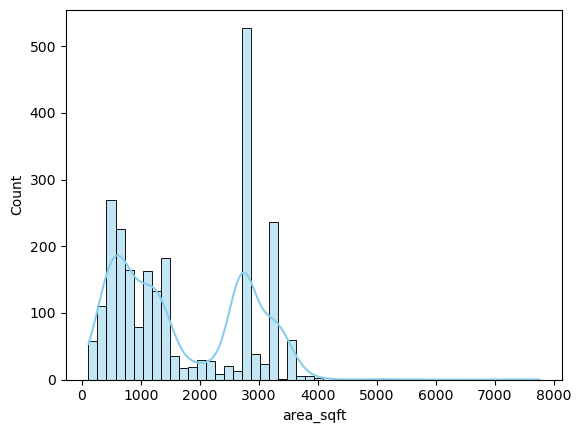

In [232]:
sns.histplot(df["area_sqft"].dropna(), bins=50, color="skyblue", kde=True)


<Axes: xlabel='area_sqft'>

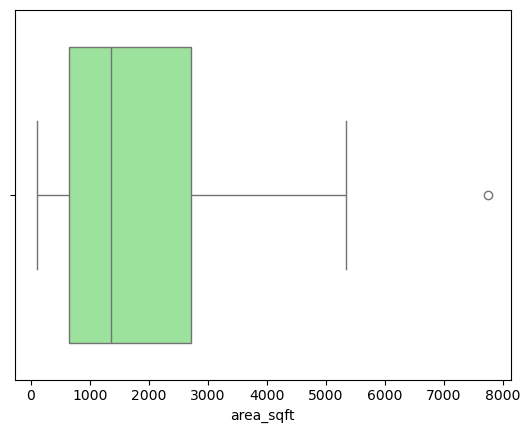

In [233]:
sns.boxplot(x=df["area_sqft"].dropna(), color="lightgreen")

**Area (sqft) — Observations**
- Most properties fall between **~650 and 2,723 sqft** (IQR).  
- Median area is **~1,361 sqft**; mean is **~1,689 sqft**, showing right‑skew.  
- A few large properties extend up to **~7,759 sqft**, creating high‑end outliers.  


## marla


In [234]:
df["marla"].isnull().sum()


np.int64(0)

In [235]:
df["marla"].describe()


count    2463.000000
mean        6.205197
std         3.976709
min         0.400000
25%         2.400000
50%         5.000000
75%        10.000000
max        28.500000
Name: marla, dtype: float64

<Axes: xlabel='marla', ylabel='Count'>

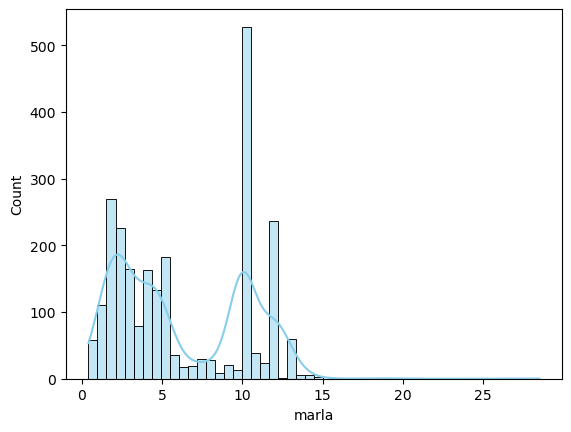

In [236]:
sns.histplot(df["marla"].dropna(), bins=50, color="skyblue", kde=True)


<Axes: xlabel='marla'>

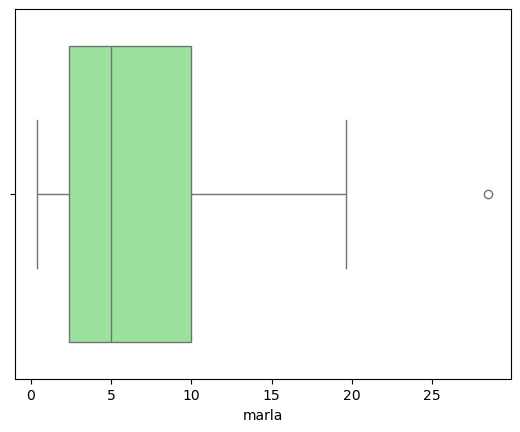

In [237]:
sns.boxplot(x=df["marla"].dropna(), color="lightgreen")


## luxury_score

In [238]:
df["luxury_score"].isnull().sum()


np.int64(0)

In [239]:
df["luxury_score"].describe()


count    2463.000000
mean      105.653674
std        33.037283
min         0.000000
25%        92.000000
50%       115.000000
75%       132.000000
max       140.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

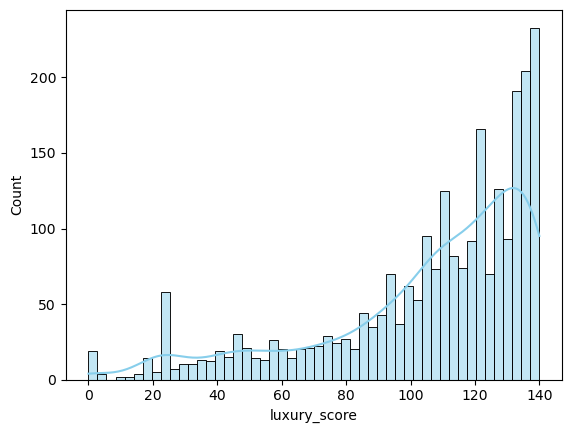

In [240]:
sns.histplot(df["luxury_score"], bins=50, color="skyblue", kde=True)


<Axes: xlabel='luxury_score'>

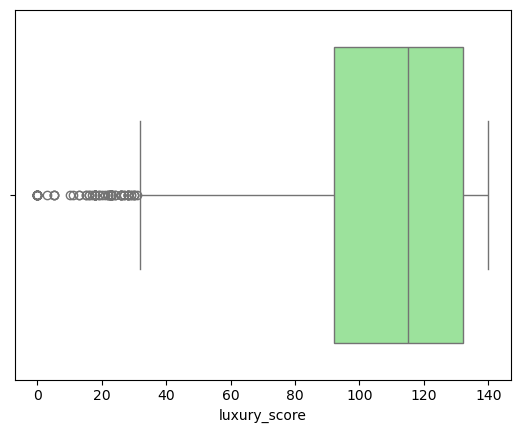

In [241]:
sns.boxplot(x=df["luxury_score"], color="lightgreen")


## Pandas profiling

**Pandas Profiling** (now `ydata-profiling`) is an automated EDA tool that generates an HTML report with summary stats, distributions, missing values, correlations, and sample data. It gives a quick overview without writing manual plots.


In [242]:
import pandas as pd
from ydata_profiling import ProfileReport

# df = pd.read_csv("lahore_flats_feature_engineered.csv").drop_duplicates()

profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
profile.to_file("output_report_v2.html")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 26.81it/s]


In [243]:
df.to_csv("flats_data_unianalysis.csv", index=False)

## Multivarient analysis